## This notebook presents the result analysis and visualization for submission NCOMMS-26-018997-T

**Title:** *Impacts and Benefits of Electrified Space Heating on Renewable-Based Power Systems*

This notebook contains the analysis of simulation results and the corresponding visualizations prepared for the above submission.

Extended Data Figure 3; Extended Data Figure 4: Breakdown of HP electricity demand across old and new buildings under different
future scenarios.

**Contact:** Yi Guo  
**Email:** yi.guo@bit.edu.cn

In [1]:
# initialize all the packages necessary
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from scipy.io import loadmat
from scipy.optimize import curve_fit
from matplotlib.patches import Patch


## Data loading and scenario-level aggregation

This section loads canton-level flexibility data for all years and scenarios, extracts the relevant building and heat pump indicators, and aggregates them to the national level. It computes annual HP electricity demand, annual flexible energy, and several normalized indicators that are later used in the figures.


In [2]:
# -----------------------------
# Basic settings
# -----------------------------
cantons = ['AG', 'AI', 'AR', 'BE', 'BL', 'BS', 'FR', 'GE', 'GL', 'GR', 'JU', 'LU', 'NE', 'NW', 'OW', 'SG', 'SH', 'SO',
           'SZ', 'TG', 'TI', 'UR', 'VD', 'VS', 'ZG', 'ZH']
years = [str(year) for year in range(2021, 2051)]

Scenarios = ['RCP26Quant50', 'RCP26Quant75', 'RCP26Quant95', 'RCP26Quant165',
             'RCP45Quant50', 'RCP45Quant75', 'RCP45Quant95', 'RCP45Quant165',
             'RCP85Quant50', 'RCP85Quant75', 'RCP85Quant95', 'RCP85Quant165']

Cases = {
    'RCP26Quant50': 'case1a',
    'RCP26Quant75': 'case1b',
    'RCP26Quant95': 'case1c',
    'RCP26Quant165': 'case1d',
    'RCP45Quant50': 'case1e',
    'RCP45Quant75': 'case1f',
    'RCP45Quant95': 'case1g',
    'RCP45Quant165': 'case1h',
    'RCP85Quant50': 'case1i',
    'RCP85Quant75': 'case1j',
    'RCP85Quant95': 'case1k',
    'RCP85Quant165': 'case1l'
}

# -----------------------------
# Helper functions
# -----------------------------
def unwrap_cell(x):
    """Recursively unwrap a cell array or object array until a numeric array is obtained"""
    arr = x
    while isinstance(arr, np.ndarray) and arr.dtype == object:
        arr = arr[0]
    return arr

def to_array64(x):
    """Convert input to a float64 array"""
    arr = unwrap_cell(x)
    return np.array(arr, dtype=np.float64).squeeze()

def total_sum(x):
    """Return the sum of a scalar or array; return 0 for empty input"""
    a = to_array64(x)
    return float(np.nansum(a)) if a.size else 0.0

def safe_div(num, den):
    """Safe division"""
    return float(num) / float(den) if den not in (0, 0.0) else np.nan

# -----------------------------
# Main loop
# -----------------------------
scenario_data = {scenario: [] for scenario in Scenarios}

for scenario in Scenarios:
    for year in years:
        flex_agg_CH_year_old = 0.0
        flex_agg_CH_year_new = 0.0
        energy_consumption_CH_year_old = 0.0
        energy_consumption_CH_year_new = 0.0
        Nbuildings_CH = 0.0
        NHPs_CH = 0.0

        for canton in cantons:
            path = (f'../Output_data/flexibility_demand_quantification/{Cases[scenario]}/canton flexibility data/{year}/{canton}.mat')

            M = loadmat(path)
            F = M['Flexibilities']
            old = F['old_buildings'][0][0][0]
            new = F['new_buildings'][0][0][0]

            # --- N_buildings / N_HPs ---
            Nbuildings_old = total_sum(old['N_buildings'])
            NHPs_old       = total_sum(old['N_HPs'])
            Nbuildings_new = total_sum(new['N_buildings'])
            NHPs_new       = total_sum(new['N_HPs'])

            delta_b = Nbuildings_new + Nbuildings_old
            delta_h = NHPs_new + NHPs_old

            Nbuildings_CH += delta_b
            NHPs_CH       += delta_h

            # --- Energy and power data ---
            Emax_old  = to_array64(old['Emax'])
            Emin_old  = to_array64(old['Emin'])
            Pbase_old = to_array64(old['Pbase'])

            Emax_new  = to_array64(new['Emax'])
            Emin_new  = to_array64(new['Emin'])
            Pbase_new = to_array64(new['Pbase'])

            # Automatically determine the final available day index
            if Emax_old.ndim == 2 and Emax_new.ndim == 2:
                h_idx = min(Emax_old.shape[0], Emax_new.shape[0]) - 1
                flex_agg_canton_year_old = float(np.nansum(Emax_old[h_idx] - Emin_old[h_idx]))
                flex_agg_canton_year_new = float(np.nansum(Emax_new[h_idx] - Emin_new[h_idx]))
            else:
                flex_agg_canton_year_old = 0.0
                flex_agg_canton_year_new = 0.0

            energy_consumption_canton_year_old = float(np.nansum(Pbase_old))
            energy_consumption_canton_year_new = float(np.nansum(Pbase_new))

            flex_agg_CH_year_old += flex_agg_canton_year_old
            flex_agg_CH_year_new += flex_agg_canton_year_new
            energy_consumption_CH_year_old += energy_consumption_canton_year_old
            energy_consumption_CH_year_new += energy_consumption_canton_year_new

        # Year-level derived indicators
        agg_flex_total = (flex_agg_CH_year_new + flex_agg_CH_year_old)
        energy_total   = (energy_consumption_CH_year_old + energy_consumption_CH_year_new)

        scenario_data[scenario].append({
            'year': int(year),
            'aggregated_flex_year_old (TWh)':  flex_agg_CH_year_old / 1000.0,
            'aggregated_flex_year_new (TWh)':  flex_agg_CH_year_new / 1000.0,
            'aggregated_flex_year_total (TWh)': agg_flex_total / 1000.0,
            'individual_flex (MWh)':            safe_div(agg_flex_total * 1000.0, NHPs_CH),
            'energy consumption year_old (TWh)': energy_consumption_CH_year_old / 1000.0,
            'energy consumption year_new (TWh)': energy_consumption_CH_year_new / 1000.0,
            'energy consumption year_total (TWh)': energy_total / 1000.0,
            'individual_consumption (MWh)':       safe_div(energy_total * 1000.0, NHPs_CH),
            'N of Bldg': Nbuildings_CH,
            'N of HPs':  NHPs_CH,
            'HP Penetration': safe_div(NHPs_CH, Nbuildings_CH),
            'Flexibility per bldg (MWh)': safe_div(agg_flex_total * 1000.0, Nbuildings_CH)
        })

# -----------------------------
# Convert to a DataFrame
# -----------------------------
dfs = {scenario: pd.DataFrame(data) for scenario, data in scenario_data.items()}


## Extended Data Figure 3: Stacked area plots of annual HP electricity demand by building type

This section visualizes annual HP electricity demand as stacked areas for old and new buildings across all scenarios. It highlights how the contribution of each building category evolves over time under different climate and adoption pathways.

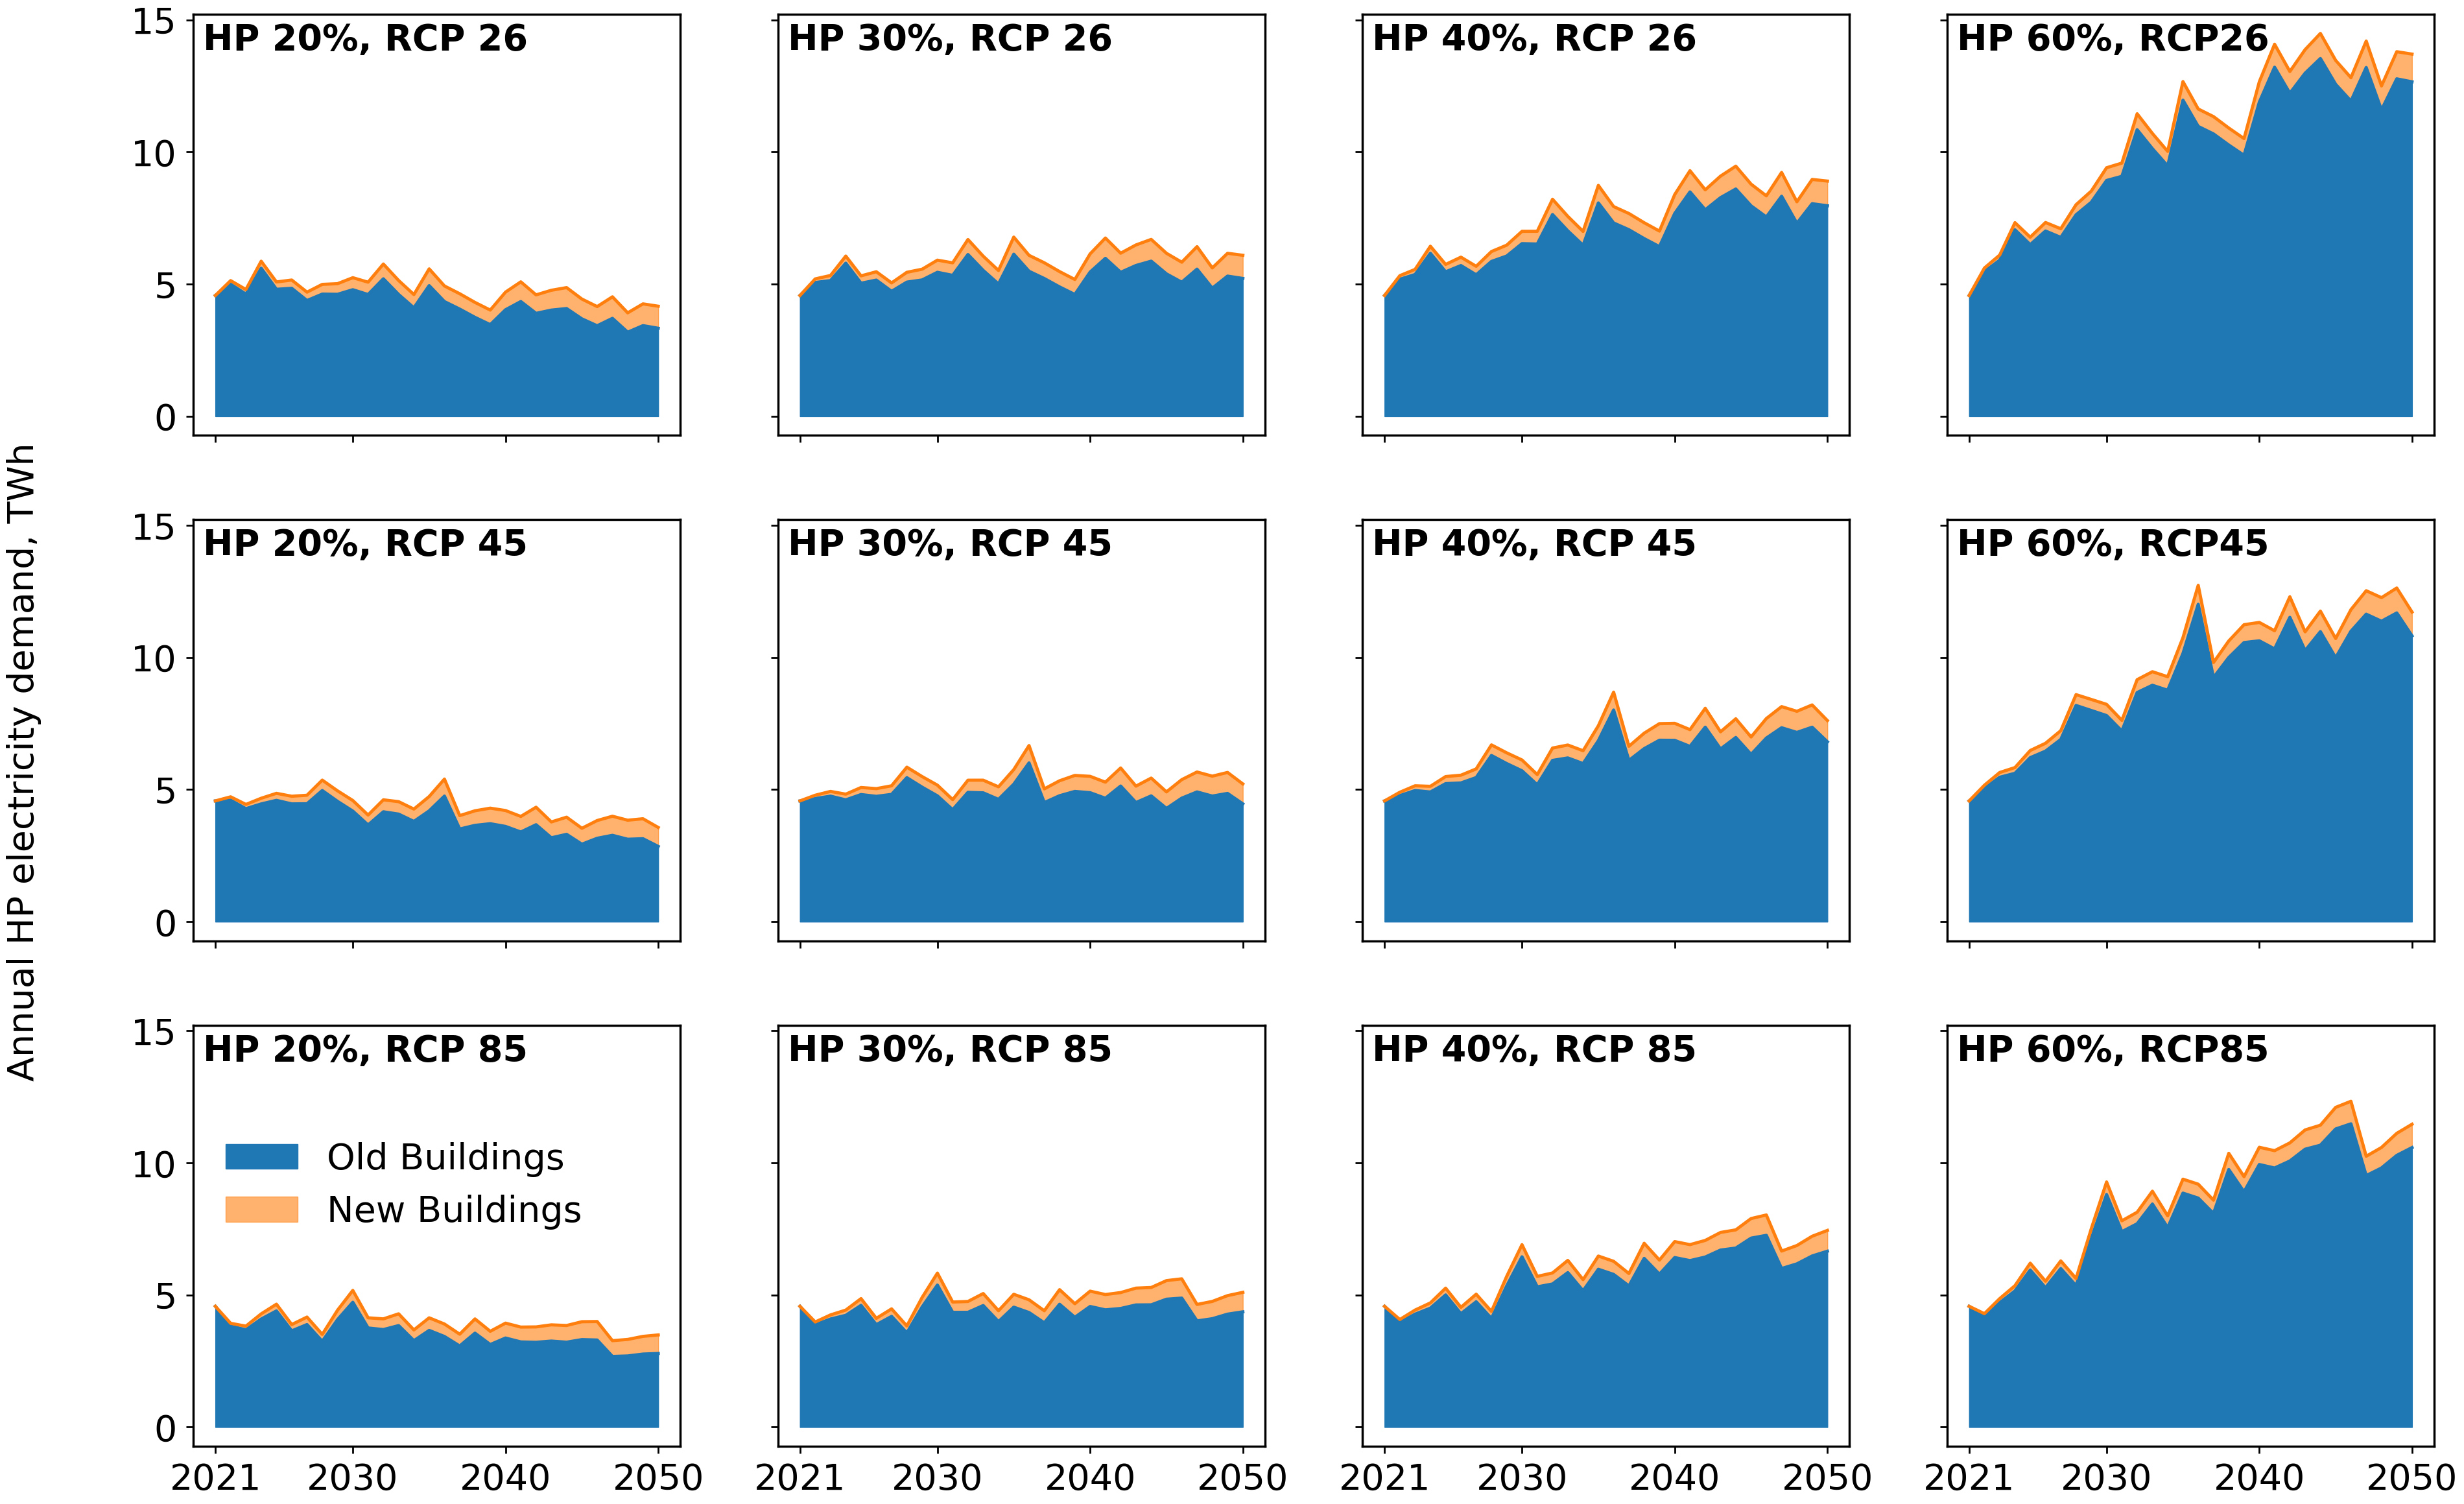

In [3]:
# ================== Adjustable parameters (centralized control) ==================
# Colors (use a seaborn palette if available; otherwise use the default palette)
USE_SEABORN = True
PALETTE_NAME = None  # For example, "Paired" or "Set2"; use None for the default palette
old_alpha = 1.0
new_alpha = 0.6

# Unified control of fonts and line widths
title_font_size   = 40
textlabel_font_size = 40   # In-panel subtitle (HP XX%, RCP XX)
tick_font_size    = 40
sublabel_font_size = 40    # Global x/y axis labels
label_font_size   = 40     # Legend font size
spine_linewidth   = 2.5    # Axis spine line width
tick_width        = 2.0
tick_length       = 8.0
line_width        = 3.5    # Outline line width

# Subplot layout and spacing control
nrows, ncols = 3, 4
figsize = (36, 24)
# Figure margins (relative values from 0 to 1): left, right, bottom, top
margins = dict(left=0.02, right=0.98, bottom=0.06, top=0.98)
# Horizontal and vertical spacing between subplots (relative axis fraction)
wspace = 0.2
hspace = 0.2

# Year tick positions
years_to_display = [2021, 2030, 2040, 2050]

# Legend settings (placed inside the bottom-left subplot)
legend_on_bottom_left_subplot = True
legend_loc_in_subplot = "upper left"   # Can be changed to "lower left", "upper right", "center", etc.
legend_frameon = False
legend_bbox_to_anchor = None           # For example, use (0.02, 0.98) for fine adjustment; None uses the default placement
# ========================================================

# Optional: if seaborn is installed, use its color palette; otherwise use the default matplotlib colors
try:
    if USE_SEABORN:
        import seaborn as sns
        color_bar = sns.color_palette(PALETTE_NAME) if PALETTE_NAME else sns.color_palette()
    else:
        raise ImportError
except Exception:
    color_bar = plt.rcParams['axes.prop_cycle'].by_key().get('color', ['C0','C1','C2','C3','C4','C5','C6','C7'])

# Color settings (area fills and outlines can share colors or differ slightly by transparency)
old_building_color_area = color_bar[0]
new_building_color_area = color_bar[1]
old_building_color_line = color_bar[0]
new_building_color_line = color_bar[1]

# ===== Subplot grid: 12 scenarios arranged in 3 rows × 4 columns =====
fig, axs = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
axs = axs.flatten()

# ===== The subtitles no longer include subplot letters =====
subtitles = [
    "HP 20%, RCP 26", "HP 30%, RCP 26", "HP 40%, RCP 26", "HP 60%, RCP26",
    "HP 20%, RCP 45", "HP 30%, RCP 45", "HP 40%, RCP 45", "HP 60%, RCP45",
    "HP 20%, RCP 85", "HP 30%, RCP 85", "HP 40%, RCP 85", "HP 60%, RCP85",
]

# ===== This section assumes `dfs` is a dictionary of the form {scenario_name: DataFrame}, with a length of 12 =====
# Each DataFrame must contain at least the following columns:['year', 'energy consumption year_old (TWh)', 'energy consumption year_total (TWh)']
# Example: dfs = {"HP13_RCP26": df1, "HP25_RCP26": df2, ...}
assert 'dfs' in globals(), "Please define `dfs` before running this cell (dict: {scenario: DataFrame})."

# Safety check: if counts are inconsistent, draw using the minimum available length
num_axes = len(axs)
num_subtitles = len(subtitles)
num_dfs = len(list(globals()['dfs'].items()))
num_draw = min(num_axes, num_subtitles, num_dfs)

# ===== Style helper: apply consistent axis formatting =====
def style_axis(ax):
    for side in ['bottom', 'top', 'left', 'right']:
        ax.spines[side].set_color('black')
        ax.spines[side].set_linewidth(spine_linewidth)
    ax.tick_params(axis='x', which='major', pad=10, width=tick_width, length=tick_length, labelsize=tick_font_size)
    ax.tick_params(axis='y', which='major', pad=10, width=tick_width, length=tick_length, labelsize=tick_font_size)
    ax.grid(False)

for ax in axs:
    style_axis(ax)

# ===== Generate the figure =====
for i, (ax, (scenario, df), subtitle) in enumerate(zip(axs[:num_draw], list(dfs.items())[:num_draw], subtitles[:num_draw])):
    # Sort by year to avoid plotting issues caused by unordered rows
    df = df.sort_values('year')

    y_old = df['energy consumption year_old (TWh)'].to_numpy()
    y_tot = df['energy consumption year_total (TWh)'].to_numpy()
    x = df['year'].to_numpy()

    # Stacked fill: old buildings (0 to y_old) and new buildings (y_old to y_tot)
    ax.fill_between(x, 0, y_old, color=old_building_color_area, alpha=old_alpha, label='Old Buildings')
    ax.fill_between(x, y_old, y_tot, color=new_building_color_area, alpha=new_alpha, label='New Buildings')

    # Outline curves
    ax.plot(x, y_old, color=old_building_color_line, linewidth=line_width)
    ax.plot(x, y_tot, color=new_building_color_line, linewidth=line_width)

    # Place the scenario subtitle at the upper-left corner inside each subplot
    ax.text(0.02, 0.98, subtitle, transform=ax.transAxes,
            fontsize=textlabel_font_size, fontweight='bold', va='top', ha='left')

    # Apply consistent x-axis ticks
    ax.set_xticks(years_to_display)

# Display tick labels only on the outer axes to avoid repetition inside the grid
for ax in axs:
    ax.label_outer()

# Global axis labels
# fig.text(0.5, margins['bottom'] - 0.02, 'Year', ha='center', fontsize=sublabel_font_size)
fig.text(margins['left'] - 0.08, 0.5, 'Annual HP electricity demand, TWh', va='center', rotation='vertical', fontsize=sublabel_font_size)

# Place the legend inside the bottom-left subplot
if legend_on_bottom_left_subplot:
    # Index of the bottom-left subplot: first column in the last row
    bottom_left_index = (nrows - 1) * ncols + 0
    legend_ax = axs[bottom_left_index]

    # Build a unified legend using handles from the first valid axis
    first_ax = axs[0]
    handles, labels = first_ax.get_legend_handles_labels()

    if handles:
        legend_ax.legend(handles, labels,
                 loc=legend_loc_in_subplot,
                 bbox_to_anchor=(0.0, 0.80),  # Example: move the legend downward if needed
                 fontsize=label_font_size,
                 frameon=legend_frameon)

else:
    # Alternative: if preferred, place the legend at the bottom of the full figure using fig.legend
    first_ax = axs[0]
    handles, labels = first_ax.get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, margins['bottom'] - 1),
                   fontsize=label_font_size, ncol=2, frameon=False)

# Layout and spacing are controlled by the centralized parameters above
plt.subplots_adjust(left=margins['left'], right=margins['right'],
                    bottom=margins['bottom'], top=margins['top'],
                    wspace=wspace, hspace=hspace)

plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'

# ======================= Additional step: export as SVG (text remains editable in Adobe Illustrator) =======================
# Keep SVG text as editable text rather than converting it to paths
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False      # Disable LaTeX rendering to avoid converting text to outlines
mpl.rcParams['font.family'] = ['Arial']

# # Output path (modify as needed)
# out_path = Path.cwd() / "EX_fig2.svg"

# # Save as SVG with a transparent background and tight margins
# fig.savefig(
#     out_path,
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     facecolor='none',
#     edgecolor='none',
#     transparent=True
# )
# print(f"Saved SVG to: {out_path}")
# ================================================================================

plt.show()


### Extended Data Figure 4: Stacked area plots of annual HP flexible energy by building type

This section visualizes annual flexible HP energy as stacked areas for old and new buildings across all scenarios. The figure is intended to show how building stock composition affects the evolution of aggregate flexibility over time.

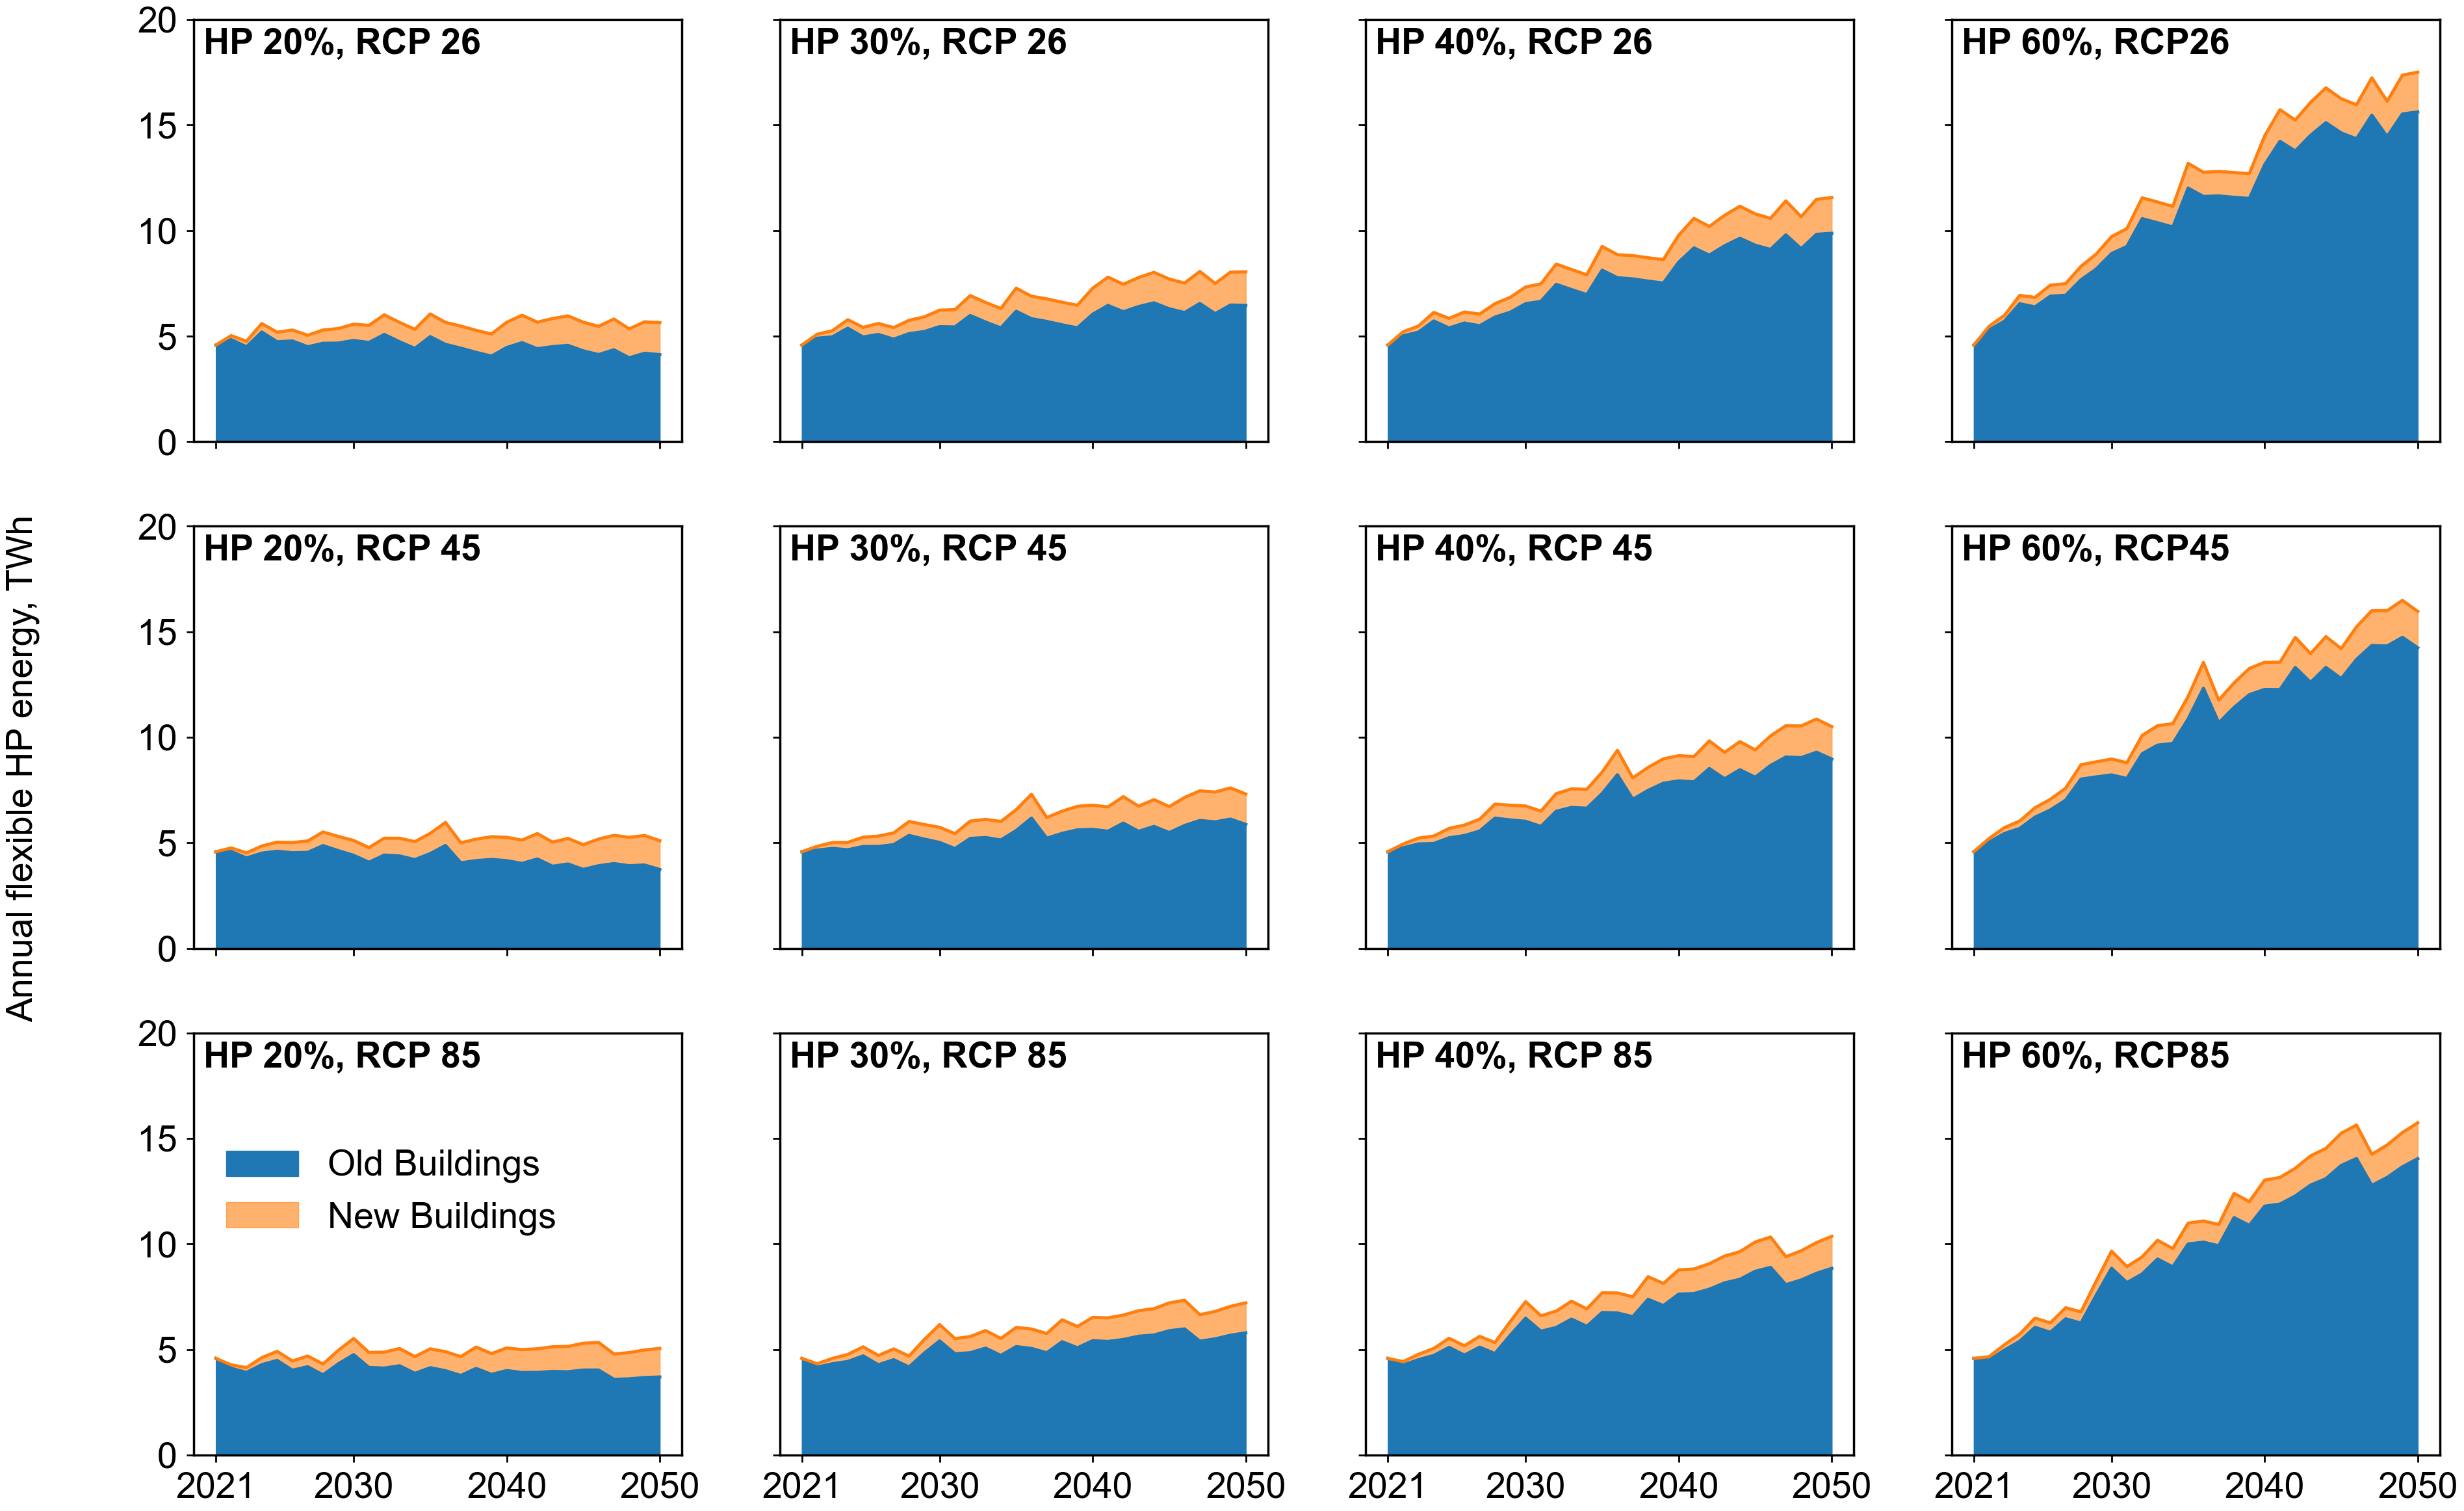

In [4]:
# ================== Adjustable parameters (centralized control) ==================
# Colors (use a seaborn palette if available; otherwise use the default palette)
USE_SEABORN = True
PALETTE_NAME = None  # For example, "Paired" or "Set2"; use None for the default palette
old_alpha = 1.0
new_alpha = 0.6

# Unified control of fonts and line widths
title_font_size   = 40
textlabel_font_size = 40   # In-panel subtitle (HP XX%, RCP XX)
tick_font_size    = 40
sublabel_font_size = 40    # Global x/y axis labels
label_font_size   = 40     # Legend font size
spine_linewidth   = 2.5    # Axis spine line width
tick_width        = 2.0
tick_length       = 8.0
line_width        = 3.5    # Outline line width

# Subplot layout and spacing control
nrows, ncols = 3, 4
figsize = (36, 24)
# Figure margins (relative values from 0 to 1): left, right, bottom, top
margins = dict(left=0.02, right=0.98, bottom=0.06, top=0.98)
# Horizontal and vertical spacing between subplots (relative axis fraction)
wspace = 0.2
hspace = 0.2

# Year tick positions
years_to_display = [2021, 2030, 2040, 2050]

# Legend settings (placed inside the bottom-left subplot)
legend_on_bottom_left_subplot = True
legend_loc_in_subplot = "upper left"   # Can be changed to "lower left", "upper right", "center", etc.
legend_frameon = False
legend_bbox_to_anchor = (0.0, 0.80)    # Fine-tune the legend position within the subplot

# Y-axis range
ylim = [0, 20]
# ========================================================

# Optional: if seaborn is installed, use its color palette; otherwise use the default matplotlib colors
try:
    if USE_SEABORN:
        import seaborn as sns
        color_bar = sns.color_palette(PALETTE_NAME) if PALETTE_NAME else sns.color_palette()
    else:
        raise ImportError
except Exception:
    color_bar = plt.rcParams['axes.prop_cycle'].by_key().get('color', ['C0','C1','C2','C3','C4','C5','C6','C7'])

# Color settings
old_building_color_area = color_bar[0]
new_building_color_area = color_bar[1]
old_building_color_line = color_bar[0]
new_building_color_line = color_bar[1]

# ===== Subplot grid: 12 scenarios arranged in 3 rows × 4 columns =====
fig, axs = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
axs = axs.flatten()

# ===== Subtitles =====
subtitles = [
    "HP 20%, RCP 26", "HP 30%, RCP 26", "HP 40%, RCP 26", "HP 60%, RCP26",
    "HP 20%, RCP 45", "HP 30%, RCP 45", "HP 40%, RCP 45", "HP 60%, RCP45",
    "HP 20%, RCP 85", "HP 30%, RCP 85", "HP 40%, RCP 85", "HP 60%, RCP85",
]

# ===== This section assumes `dfs` is a dictionary of the form {scenario_name: DataFrame}, with a length of 12 =====
assert 'dfs' in globals(), "Please define `dfs` before running this cell (dict: {scenario: DataFrame})."

# Safety check: if counts are inconsistent, draw using the minimum available length
num_axes = len(axs)
num_subtitles = len(subtitles)
num_dfs = len(list(globals()['dfs'].items()))
num_draw = min(num_axes, num_subtitles, num_dfs)

# ===== Style helper: apply consistent axis formatting =====
def style_axis(ax):
    for side in ['bottom', 'top', 'left', 'right']:
        ax.spines[side].set_color('black')
        ax.spines[side].set_linewidth(spine_linewidth)
    ax.tick_params(axis='x', which='major', pad=10, width=tick_width, length=tick_length, labelsize=tick_font_size)
    ax.tick_params(axis='y', which='major', pad=10, width=tick_width, length=tick_length, labelsize=tick_font_size)
    ax.grid(False)

for ax in axs:
    style_axis(ax)

# ===== Generate the figure =====
for i, (ax, (scenario, df), subtitle) in enumerate(zip(axs[:num_draw], list(dfs.items())[:num_draw], subtitles[:num_draw])):
    df = df.sort_values('year')

    y_old = df['aggregated_flex_year_old (TWh)'].to_numpy()
    y_tot = df['aggregated_flex_year_total (TWh)'].to_numpy()
    x = df['year'].to_numpy()

    ax.fill_between(x, 0, y_old, color=old_building_color_area, alpha=old_alpha, label='Old Buildings')
    ax.fill_between(x, y_old, y_tot, color=new_building_color_area, alpha=new_alpha, label='New Buildings')

    ax.plot(x, y_old, color=old_building_color_line, linewidth=line_width)
    ax.plot(x, y_tot, color=new_building_color_line, linewidth=line_width)

    ax.text(0.02, 0.98, subtitle, transform=ax.transAxes,
            fontsize=textlabel_font_size, fontweight='bold', va='top', ha='left')

    ax.set_xticks(years_to_display)

# Apply a consistent y-axis range
for ax in axs:
    ax.set_ylim(ylim)

# Display tick labels only on the outer axes
for ax in axs:
    ax.label_outer()

# Global axis labels
fig.text(margins['left'] - 0.08, 0.5, 'Annual flexible HP energy, TWh', va='center', rotation='vertical', fontsize=sublabel_font_size)

# Place the legend inside the bottom-left subplot
if legend_on_bottom_left_subplot:
    bottom_left_index = (nrows - 1) * ncols + 0
    legend_ax = axs[bottom_left_index]

    first_ax = axs[0]
    handles, labels = first_ax.get_legend_handles_labels()

    if handles:
        legend_ax.legend(handles, labels,
                         loc=legend_loc_in_subplot,
                         bbox_to_anchor=legend_bbox_to_anchor,
                         fontsize=label_font_size,
                         frameon=legend_frameon)

# Layout and spacing
plt.subplots_adjust(left=margins['left'], right=margins['right'],
                    bottom=margins['bottom'], top=margins['top'],
                    wspace=wspace, hspace=hspace)

# Transparent background (kept as in the original setting)
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'

# ======================= Additional step: export as SVG (text remains editable in Adobe Illustrator) =======================
# Keep SVG text as editable text rather than converting it to paths
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False      # Disable LaTeX rendering to avoid converting text to outlines
mpl.rcParams['font.family'] = ['Arial']

# # Output path (modify as needed)
# out_path = Path.cwd() / "EX_fig3.svg"

# # Save as SVG with a transparent background and tight margins
# fig.savefig(
#     out_path,
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     facecolor='none',
#     edgecolor='none',
#     transparent=True
# )
# print(f"Saved SVG to: {out_path}")
# ================================================================================

plt.show()
